In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1890]
image_error_cut = image_error[55:155, 0:1890]

In [20]:
image_error_cut

array([[0.0303987 , 0.02912354, 0.02480921, ..., 0.0067154 , 0.00691563,
        0.00693766],
       [0.03006888, 0.02813161, 0.02885036, ..., 0.00677515, 0.0061732 ,
        0.00663774],
       [0.03166641, 0.02917927, 0.03076373, ..., 0.00689471, 0.00661363,
        0.00693721],
       ...,
       [0.02708479, 0.02681352, 0.03034172, ..., 0.00661501, 0.00649011,
        0.00683801],
       [0.02696249, 0.02753854, 0.02932177, ..., 0.00645496, 0.00637915,
        0.00649103],
       [0.02817379, 0.02815345, 0.02910345, ..., 0.00675251, 0.00685232,
        0.00682028]], dtype='>f4')

Text(0.5, 0, 'wavelenght')

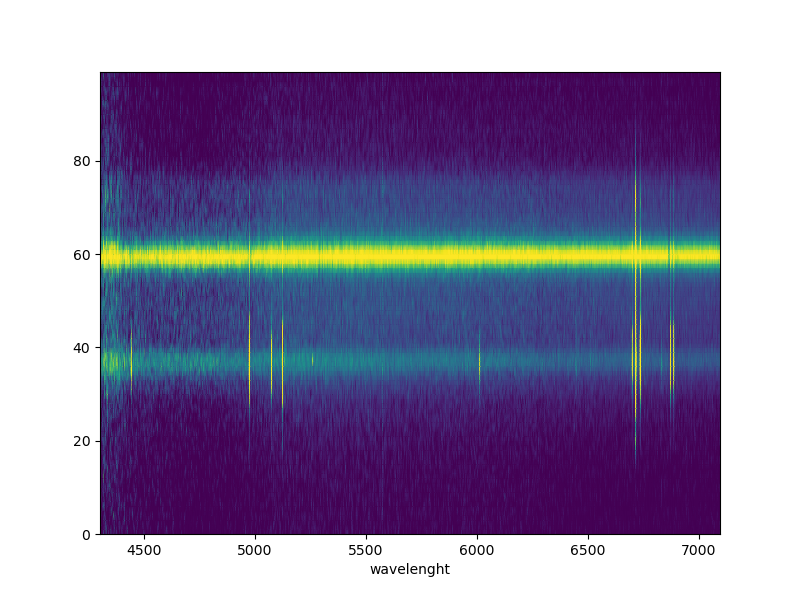

In [6]:
wavelenghts = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.figure(figsize=(8,6))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [22]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [23]:
l_NII

6739.6754

## Continuum

## Sky lines

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1890]

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 45.40277777777776, 'wavelenght')

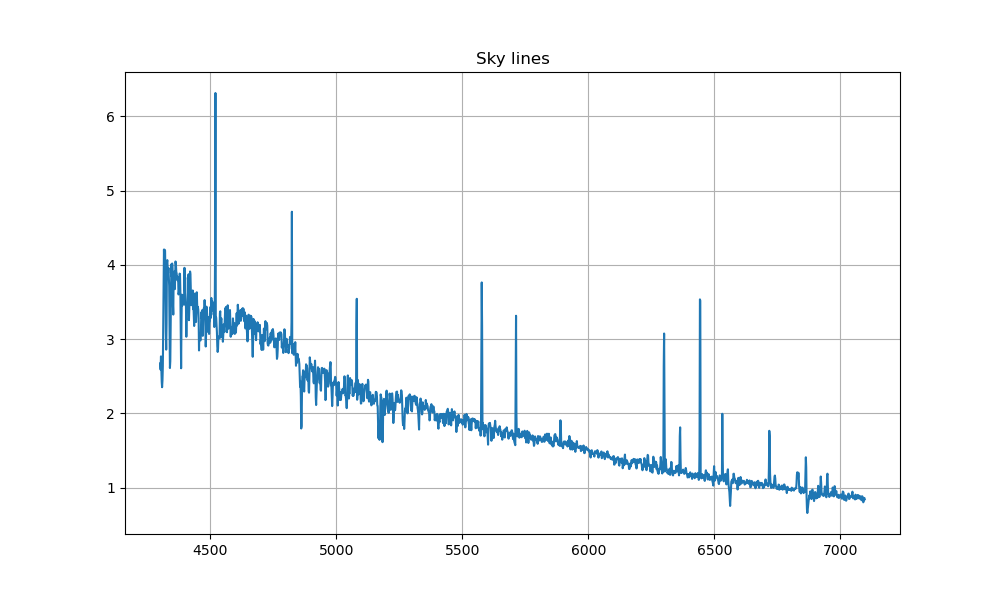

In [8]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wavelenghts, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

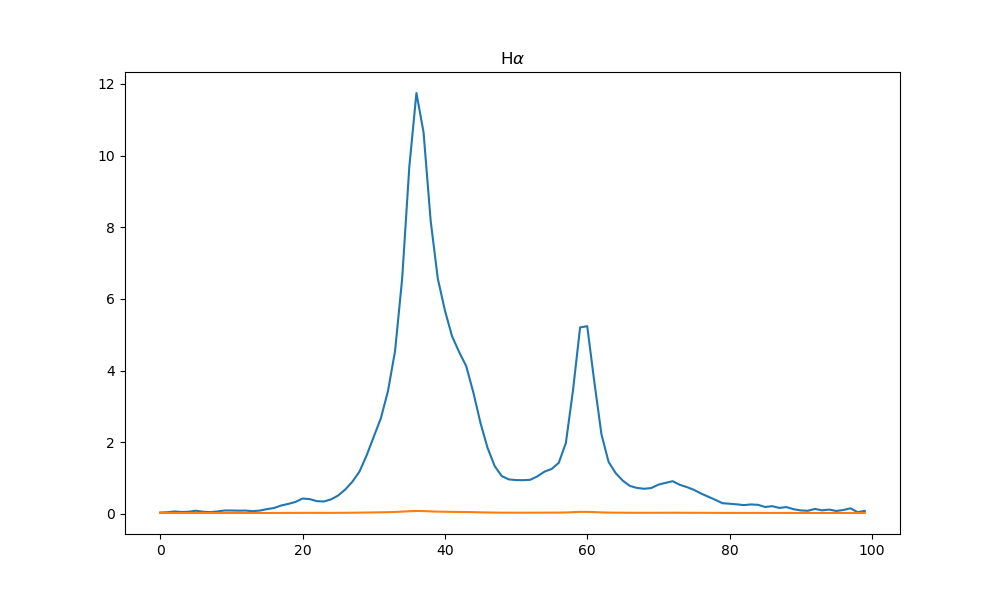

In [26]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda pesate
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [27]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 251.8253589556827
differential_evolution step 2: f(x)= 251.8253589556827
differential_evolution step 3: f(x)= 251.8253589556827
differential_evolution step 4: f(x)= 251.8253589556827
differential_evolution step 5: f(x)= 178.17645956406398
differential_evolution step 6: f(x)= 178.17645956406398
differential_evolution step 7: f(x)= 138.5918943901342
differential_evolution step 8: f(x)= 138.5918943901342
differential_evolution step 9: f(x)= 138.5918943901342
differential_evolution step 10: f(x)= 120.04377955426408
differential_evolution step 11: f(x)= 120.04377955426408
differential_evolution step 12: f(x)= 120.04377955426408
differential_evolution step 13: f(x)= 101.75420590745036
differential_evolution step 14: f(x)= 101.75420590745036
differential_evolution step 15: f(x)= 74.20559838135816
differential_evolution step 16: f(x)= 74.20559838135816
differential_evolution step 17: f(x)= 74.20559838135816
differential_evolution step 18: f(x)= 74.205598381

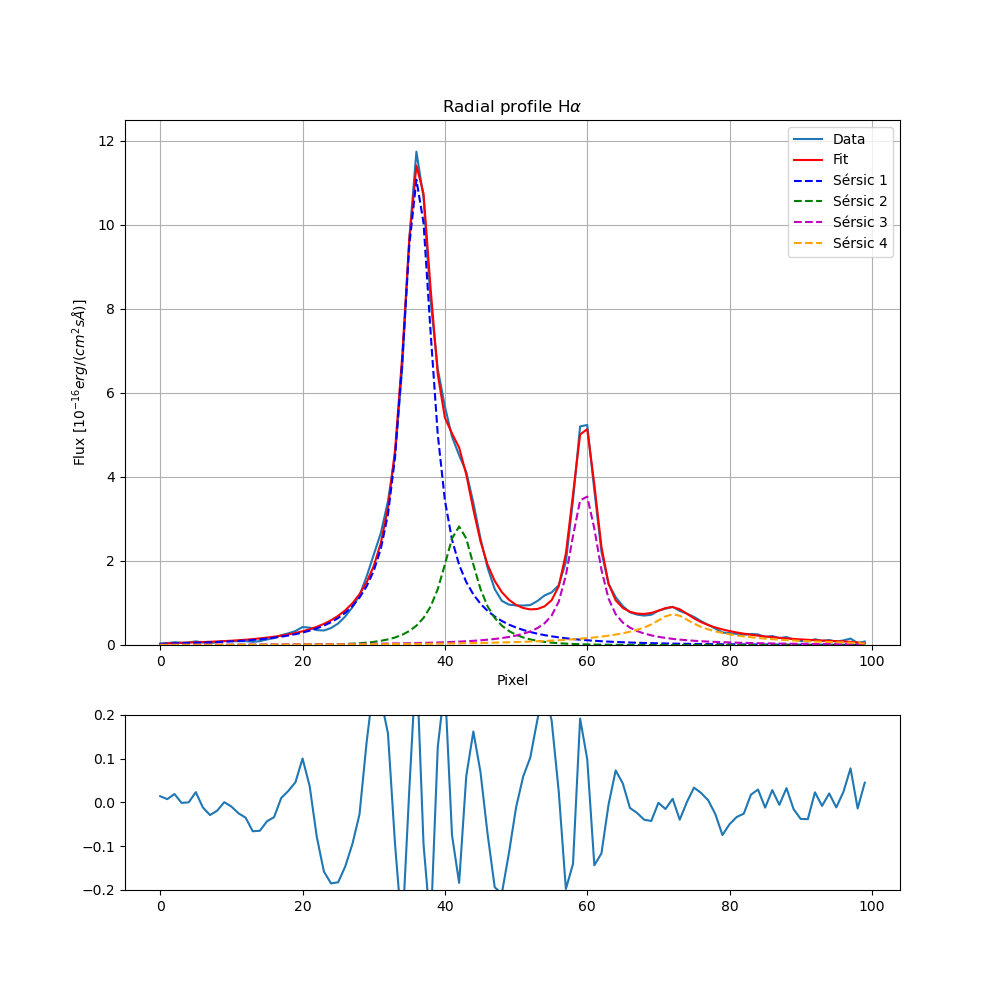

In [28]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_diff')

In [29]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0_HA = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0_HA[i] = params_curve_HA[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HA)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0_HA[i]:.4f}")

print(np.sqrt(np.diag(covariance_HA)))
#print(infodict.fvec**2)
chi2_HA = np.sum((((radial_profile_HA - model_convolved(x_axes, *params_curve_HA)) / radial_profile_error_HA)**2))
dof_HA = len(radial_profile_HA) - len(params_curve_HA)
chi2_reduced_HA = chi2_HA / dof_HA
print(chi2_reduced_HA)

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Halpha_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Halpha_fit_error.csv", float_format='%.4f')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1505369604.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:511: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1505369604.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.7336, r_e=10.0575, n=2.0273, x_0=36.1584
Sérsic 2: I_e=0.5038, r_e=5.1610, n=1.2751, x_0=42.0162
Sérsic 3: I_e=0.0480, r_e=25.1799, n=3.7772, x_0=59.5634
Sérsic 4: I_e=0.0504, r_e=25.1946, n=1.6757, x_0=72.2943
[1.82287894e-01 1.74601764e+00 1.89280335e-01 4.91852622e-02
 2.45171111e-01 1.83821823e+00 3.64305430e-01 1.76511518e-01
 3.07985599e-01 1.12917930e+02 6.52824627e+00 9.53008678e-04
 4.44955256e-02 2.75274176e+01 6.14004139e-01 4.17652854e-01]
8.722513260444575


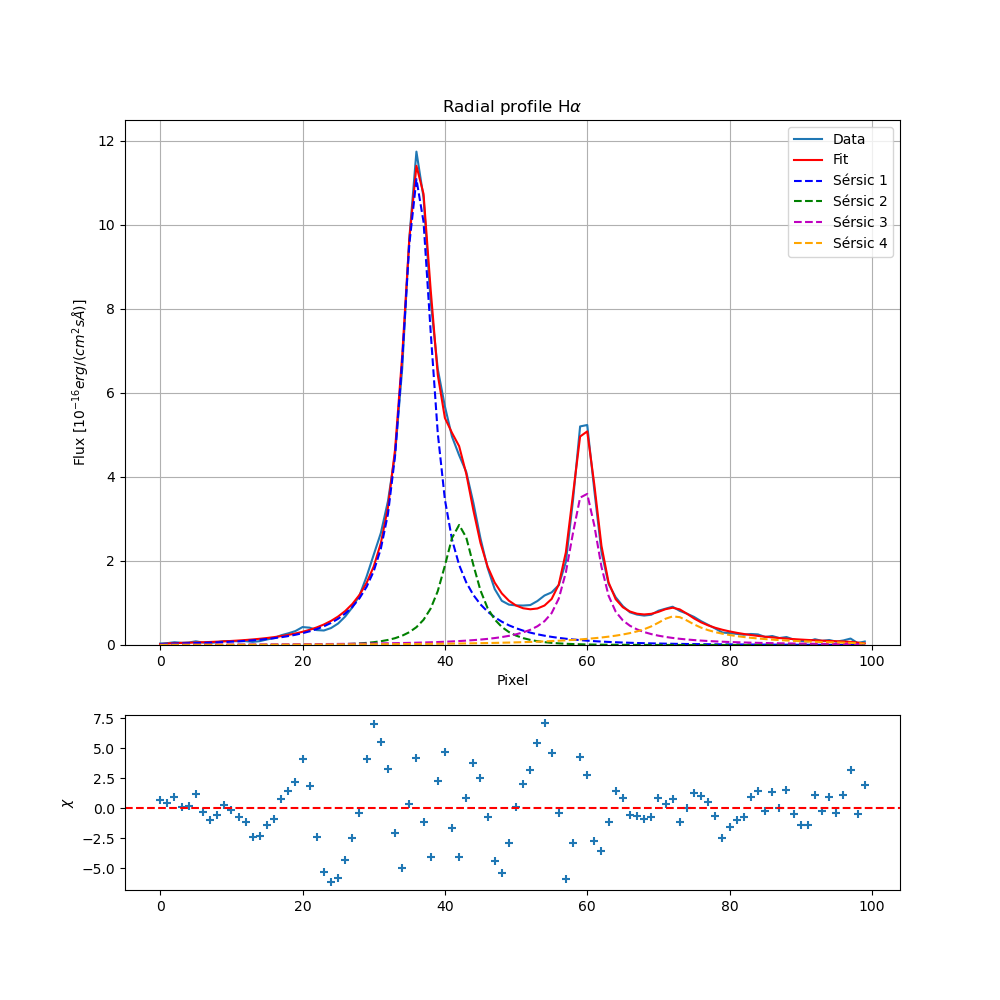

In [30]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HA)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)
#ax[0].tight_layout()

ax[1].scatter(x_axes, (radial_profile_HA - y_fit)/radial_profile_error_HA, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')

plt.savefig('Radial_profile_Halpha_curve')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

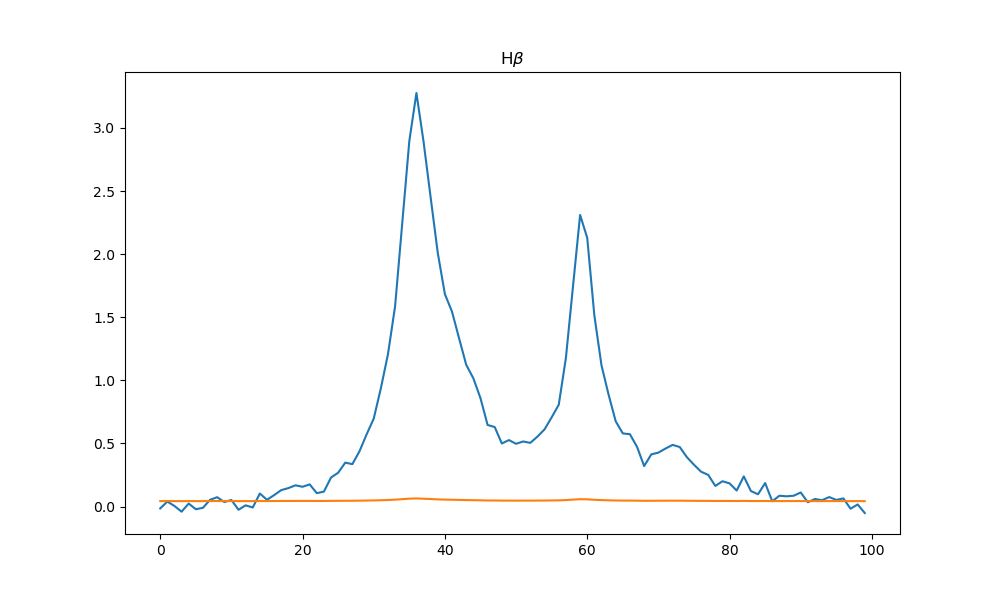

In [31]:
mask_HB = (wavelenghts > l_HB-8)*(wavelenghts < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [32]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 11.719902128379102
differential_evolution step 2: f(x)= 11.719902128379102
differential_evolution step 3: f(x)= 11.719902128379102
differential_evolution step 4: f(x)= 6.405752075085137
differential_evolution step 5: f(x)= 5.97010989410824
differential_evolution step 6: f(x)= 5.97010989410824
differential_evolution step 7: f(x)= 4.915455975149287
differential_evolution step 8: f(x)= 4.915455975149287
differential_evolution step 9: f(x)= 4.915455975149287
differential_evolution step 10: f(x)= 4.915455975149287
differential_evolution step 11: f(x)= 4.915455975149287
differential_evolution step 12: f(x)= 4.915455975149287
differential_evolution step 13: f(x)= 4.915455975149287
differential_evolution step 14: f(x)= 4.915455975149287
differential_evolution step 15: f(x)= 3.774807594885094
differential_evolution step 16: f(x)= 3.774807594885094
differential_evolution step 17: f(x)= 3.774807594885094
differential_evolution step 18: f(x)= 3.774807594885094


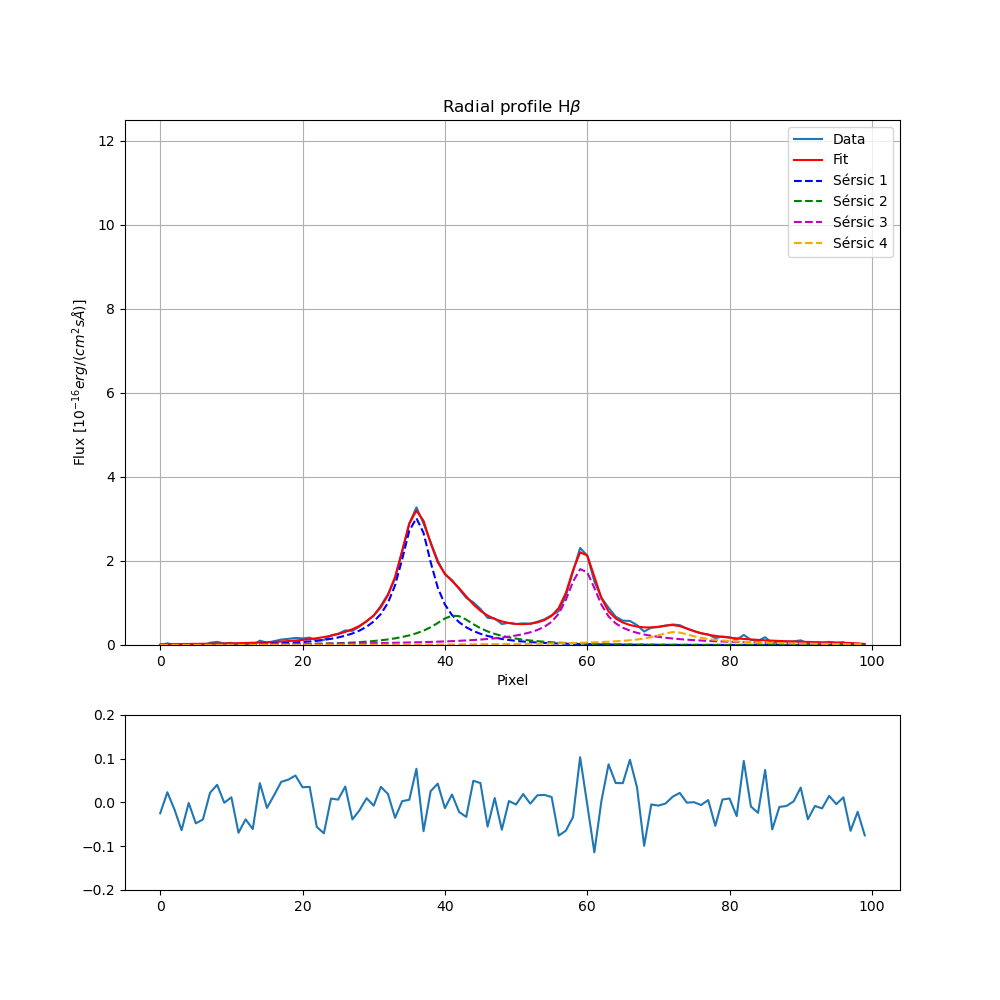

In [33]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_HB - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_Hbeta_kernel')

In [34]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_HB[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HB)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Hbeta_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Hbeta_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_HB)))
#print(infodict.fvec**2)
chi2_HB = np.sum((((radial_profile_HB - model_convolved(x_axes, *params_curve_HB)) / radial_profile_error_HB)**2))
dof_HB = len(radial_profile_HB) - len(params_curve_HB)
chi2_reduced_HB = chi2_HB / dof_HB
print(chi2_reduced_HB)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1760650217.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1760650217.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.3137, r_e=8.1046, n=1.6179, x_0=35.9367
Sérsic 2: I_e=0.1099, r_e=10.1230, n=1.2612, x_0=41.3299
Sérsic 3: I_e=0.0180, r_e=49.4053, n=3.4987, x_0=59.3653
Sérsic 4: I_e=0.0165, r_e=27.2381, n=1.9246, x_0=72.2864
[1.19871743e-01 2.60784391e+00 2.64635916e-01 7.62865043e-02
 1.05244274e-01 1.00182214e+01 6.45876573e-01 4.52519363e-01
 4.50372348e-02 9.83248290e+01 2.13371106e+00 5.29059953e-04
 2.66041828e-02 4.87344288e+01 1.07923849e+00 4.07127944e-01]
0.9494064538121814


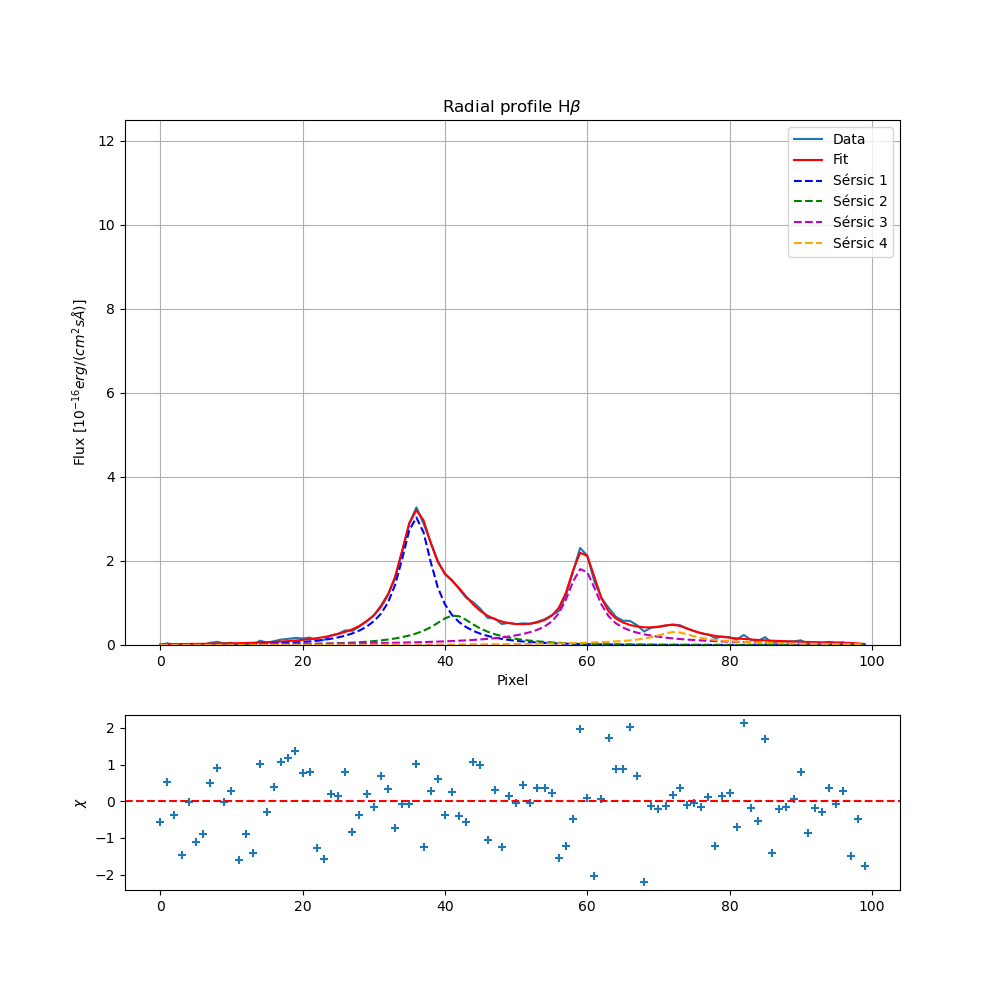

In [35]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HB)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_HB - y_fit)/radial_profile_error_HB, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

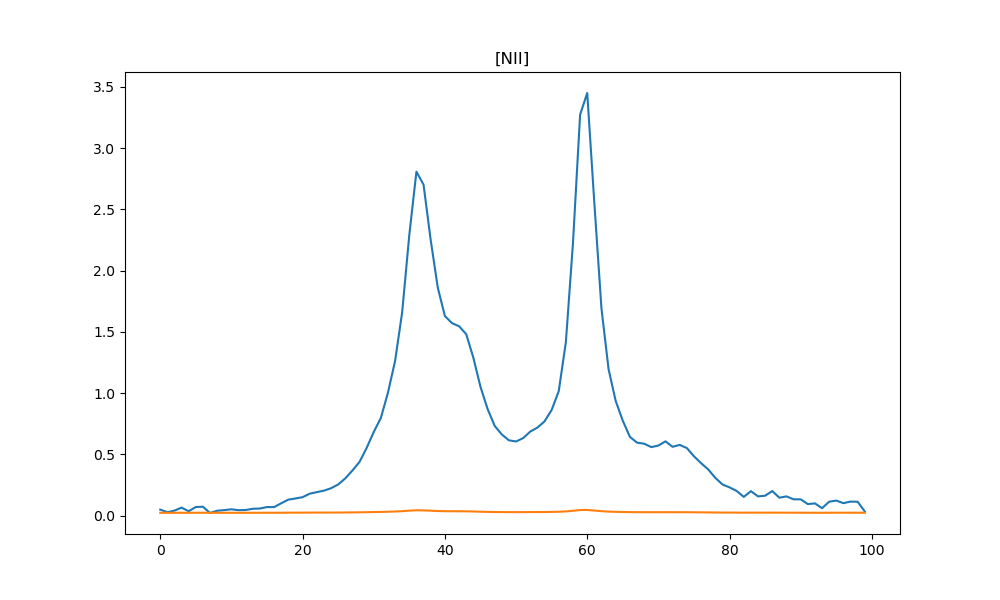

In [36]:
mask_NII = (wavelenghts > l_NII-8)*(wavelenghts < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [37]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.2),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 9.50976346227801
differential_evolution step 2: f(x)= 9.50976346227801
differential_evolution step 3: f(x)= 9.50976346227801
differential_evolution step 4: f(x)= 7.813551679126947
differential_evolution step 5: f(x)= 7.813551679126947
differential_evolution step 6: f(x)= 7.251261745461848
differential_evolution step 7: f(x)= 7.251261745461848
differential_evolution step 8: f(x)= 6.683337834851547
differential_evolution step 9: f(x)= 6.683337834851547
differential_evolution step 10: f(x)= 4.246822743216878
differential_evolution step 11: f(x)= 4.246822743216878
differential_evolution step 12: f(x)= 4.197420040568103
differential_evolution step 13: f(x)= 4.197420040568103
differential_evolution step 14: f(x)= 3.528703214375048
differential_evolution step 15: f(x)= 2.48349438146669
differential_evolution step 16: f(x)= 2.0426254711600538
differential_evolution step 17: f(x)= 2.0426254711600538
differential_evolution step 18: f(x)= 2.0426254711600538
di

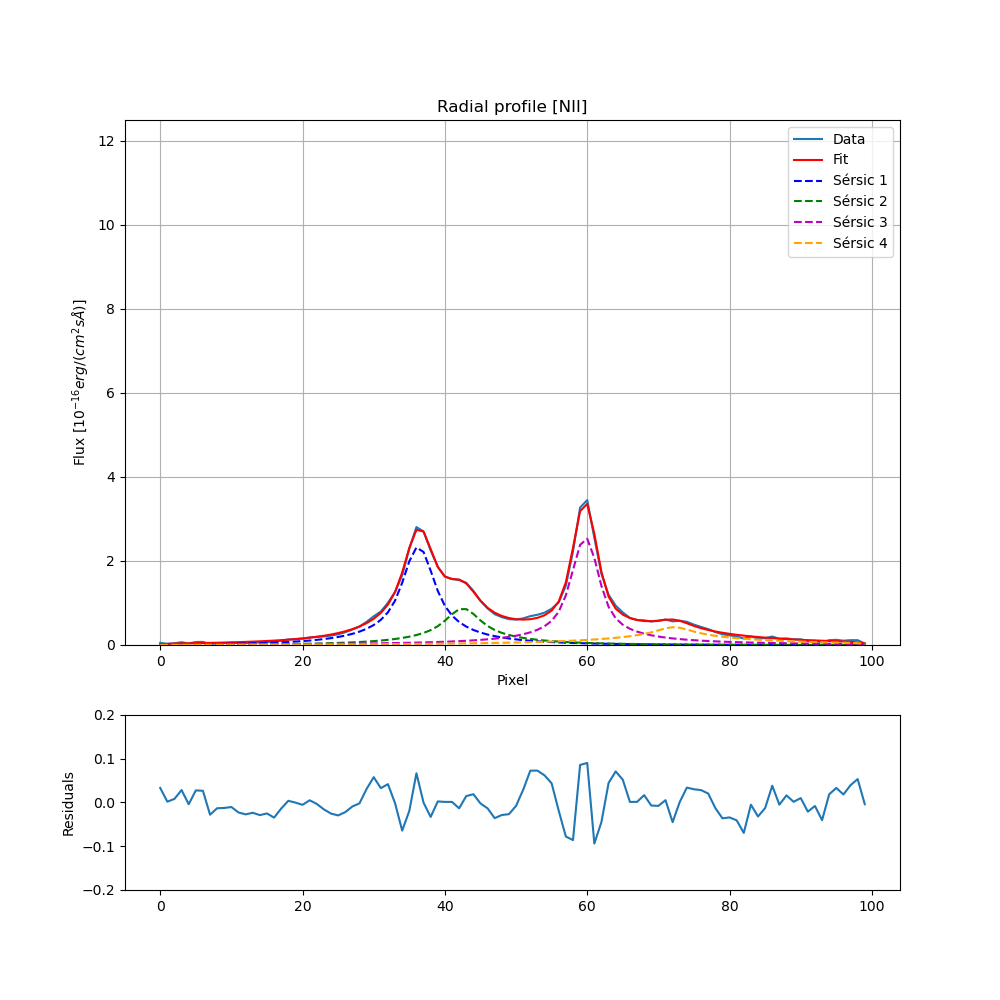

In [38]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_NII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_NII_kernel')

In [39]:
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_NII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_NII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("NII_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("NII_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_NII)))
#print(infodict.fvec**2)
chi2_NII = np.sum((((radial_profile_NII - model_convolved(x_axes, *params_curve_NII)) / radial_profile_error_NII)**2))
dof_NII = len(radial_profile_NII) - len(params_curve_NII)
chi2_reduced_NII = chi2_NII / dof_NII
print(chi2_reduced_NII)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\2331560874.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\2331560874.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.1611, r_e=12.2895, n=1.9629, x_0=36.3096
Sérsic 2: I_e=0.0734, r_e=13.5236, n=1.7192, x_0=42.5388
Sérsic 3: I_e=0.0206, r_e=44.6320, n=3.8826, x_0=59.6624
Sérsic 4: I_e=0.0311, r_e=30.7689, n=1.6184, x_0=72.3834
[6.83638185e-02 4.76921905e+00 2.97015369e-01 5.72596356e-02
 8.86135673e-02 1.69410249e+01 8.11978407e-01 1.67205386e-01
 6.88392848e-02 1.13805664e+02 2.93388646e+00 2.60955583e-04
 1.80670473e-02 2.39779270e+01 3.98189787e-01 3.28172818e-01]
1.502763178128745


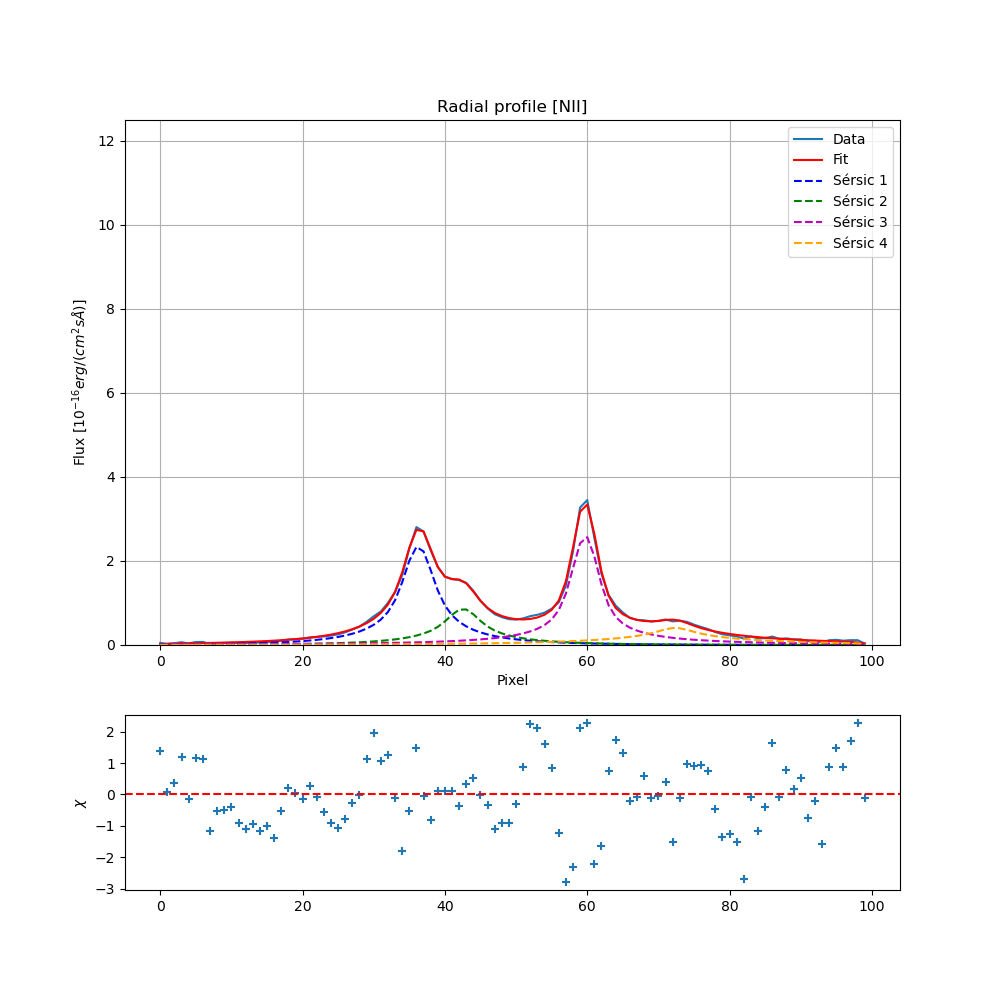

In [40]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_NII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_NII - y_fit)/radial_profile_error_NII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

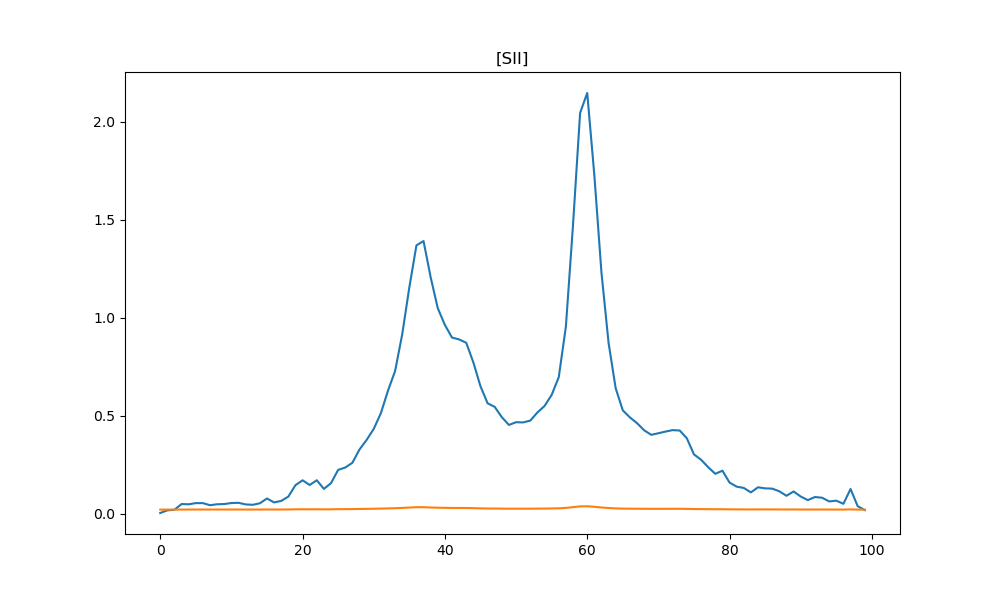

In [41]:
mask_SII = (wavelenghts > l_SII-8)*(wavelenghts < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [42]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 7.507780121077195
differential_evolution step 2: f(x)= 5.670744997801464
differential_evolution step 3: f(x)= 3.9030857297134665
differential_evolution step 4: f(x)= 3.9030857297134665
differential_evolution step 5: f(x)= 3.3941916579923816
differential_evolution step 6: f(x)= 3.3941916579923816
differential_evolution step 7: f(x)= 2.826581371031196
differential_evolution step 8: f(x)= 2.826581371031196
differential_evolution step 9: f(x)= 2.826581371031196
differential_evolution step 10: f(x)= 2.826581371031196
differential_evolution step 11: f(x)= 2.767049936754508
differential_evolution step 12: f(x)= 2.767049936754508
differential_evolution step 13: f(x)= 2.767049936754508
differential_evolution step 14: f(x)= 1.762837698871379
differential_evolution step 15: f(x)= 1.762837698871379
differential_evolution step 16: f(x)= 1.762837698871379
differential_evolution step 17: f(x)= 1.762837698871379
differential_evolution step 18: f(x)= 1.2355560120185

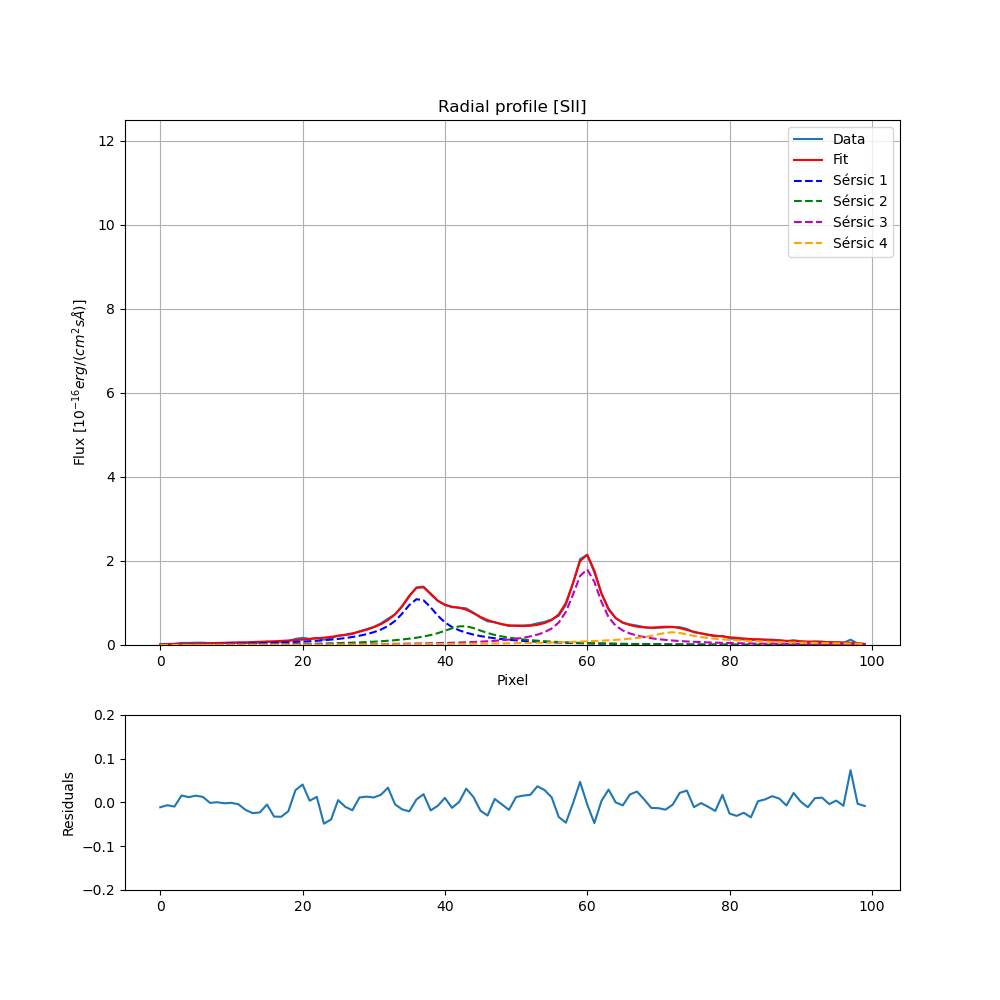

In [43]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_SII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_SII_diff')

In [44]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_SII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_SII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("SII_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("SII_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_SII)))
#print(infodict.fvec**2)
chi2_SII = np.sum((((radial_profile_SII - model_convolved(x_axes, *params_curve_SII)) / radial_profile_error_SII)**2))
dof_SII = len(radial_profile_SII) - len(params_curve_SII)
chi2_reduced_SII = chi2_SII / dof_SII
print(chi2_reduced_SII)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1536869192.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1536869192.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.0773, r_e=16.0734, n=1.8383, x_0=36.3678
Sérsic 2: I_e=0.0529, r_e=15.4693, n=1.4107, x_0=42.5300
Sérsic 3: I_e=0.0257, r_e=29.6815, n=3.3015, x_0=59.7614
Sérsic 4: I_e=0.0152, r_e=43.4966, n=1.8426, x_0=72.1189
[4.19309224e-02 9.98471039e+00 3.48850081e-01 9.17418072e-02
 5.80455973e-02 2.41529937e+01 7.53608665e-01 2.99187135e-01
 1.21352599e-01 1.08997979e+02 4.06144188e+00 8.39310132e-04
 9.69696842e-03 4.69626360e+01 4.41443949e-01 3.13108390e-01]
0.8165144488238615


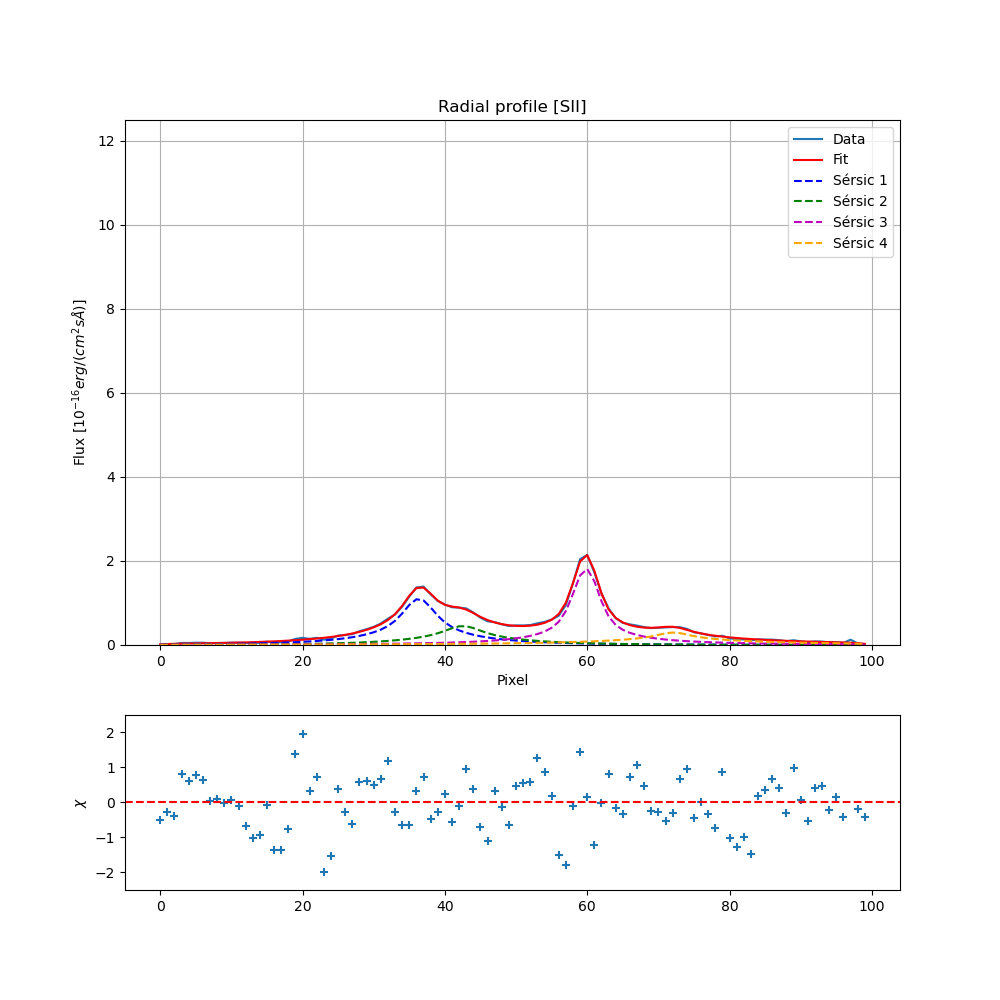

In [45]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_SII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_SII - y_fit)/radial_profile_error_SII,marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
ax[1].set_ylim(-2.5, 2.5)
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

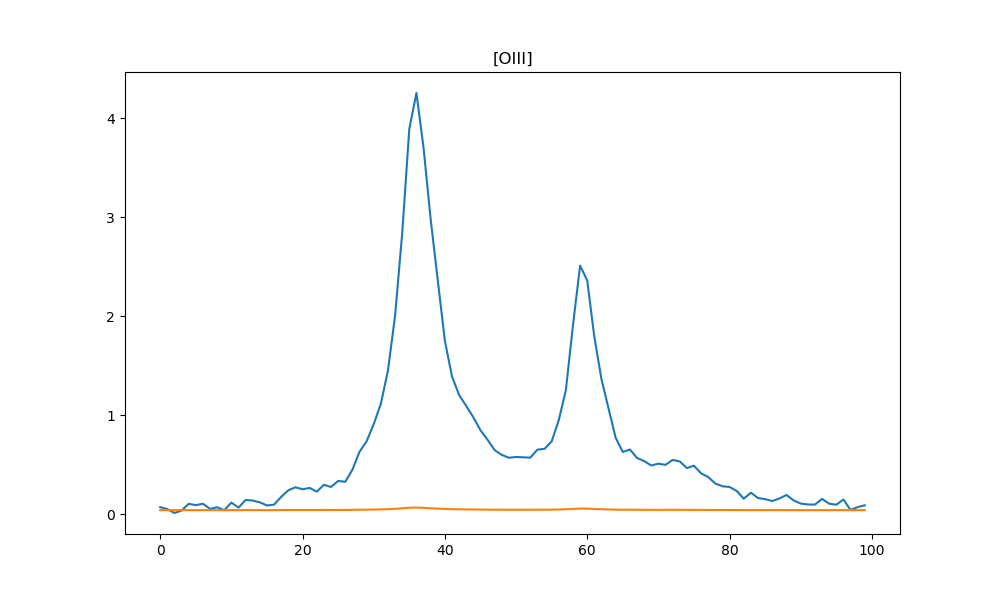

In [46]:
mask_OIII = (wavelenghts > l_OIII-8)*(wavelenghts < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [47]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 27.13964095884487
differential_evolution step 2: f(x)= 27.13964095884487
differential_evolution step 3: f(x)= 23.481807406071646
differential_evolution step 4: f(x)= 21.55854423270916
differential_evolution step 5: f(x)= 21.55854423270916
differential_evolution step 6: f(x)= 11.695154539279052
differential_evolution step 7: f(x)= 11.695154539279052
differential_evolution step 8: f(x)= 11.695154539279052
differential_evolution step 9: f(x)= 8.559699159124193
differential_evolution step 10: f(x)= 8.559699159124193
differential_evolution step 11: f(x)= 8.559699159124193
differential_evolution step 12: f(x)= 6.037655676729822
differential_evolution step 13: f(x)= 2.932489658667493
differential_evolution step 14: f(x)= 2.932489658667493
differential_evolution step 15: f(x)= 2.932489658667493
differential_evolution step 16: f(x)= 2.932489658667493
differential_evolution step 17: f(x)= 2.932489658667493
differential_evolution step 18: f(x)= 2.9324896586674

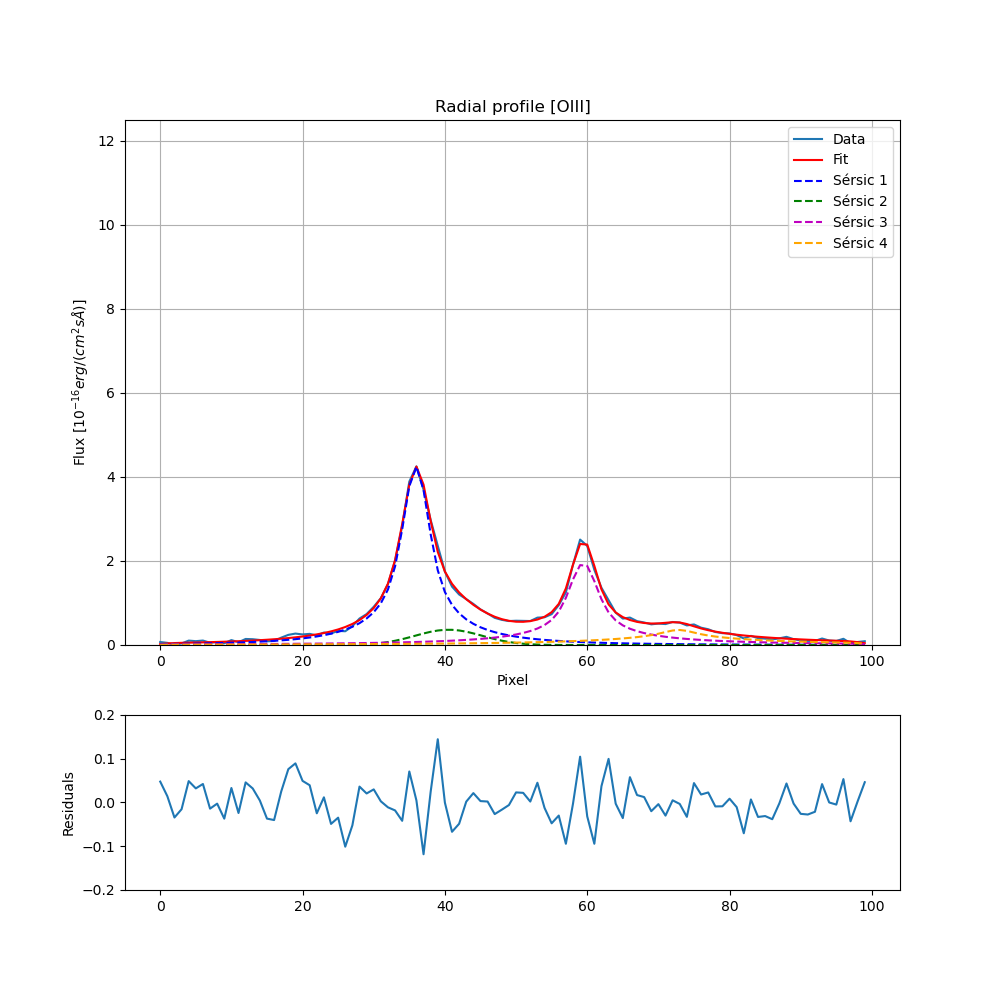

In [48]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].plot(x_axes, radial_profile_OIII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_OIII_kernel')

In [49]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_OIII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_OIII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("OIII_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("OIII_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_OIII)))
#print(infodict.fvec**2)
chi2_OIII = np.sum((((radial_profile_OIII - model_convolved(x_axes, *params_curve_OIII)) / radial_profile_error_OIII)**2))
dof_OIII = len(radial_profile_OIII) - len(params_curve_OIII)
chi2_reduced_OIII = chi2_OIII / dof_OIII
print(chi2_reduced_OIII)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\3177394038.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\3177394038.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\3177394038.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=0.1941, r_e=14.0934, n=2.1780, x_0=35.9350
Sérsic 2: I_e=0.2026, r_e=5.4064, n=0.4628, x_0=40.1025
Sérsic 3: I_e=0.0199, r_e=50.2968, n=3.4618, x_0=59.4644
Sérsic 4: I_e=0.0203, r_e=43.7106, n=1.7667, x_0=72.9169
[1.48824406e-01 6.98339316e+00 5.23231035e-01 4.90069710e-02
 1.18417252e-01 1.68763250e+00 2.14348836e-01 2.84757291e+00
 9.36069181e-02 1.88191358e+02 3.86931157e+00 1.06404336e-03
 2.21847003e-02 6.90599484e+01 7.41514383e-01 4.51604664e-01]
0.9876872380981936


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1431935089.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


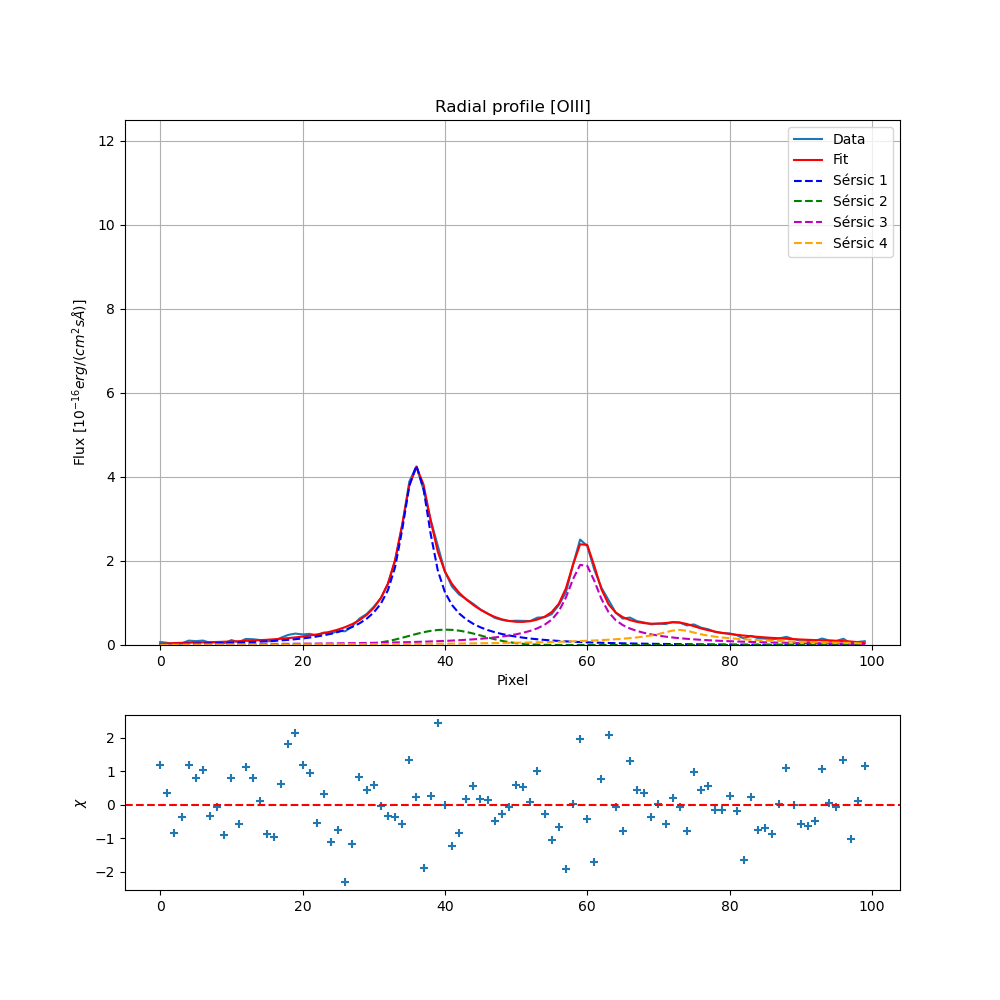

In [50]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_OIII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 12.5)

ax[1].scatter(x_axes, (radial_profile_OIII - y_fit)/radial_profile_error_OIII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_OIII_curve')

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

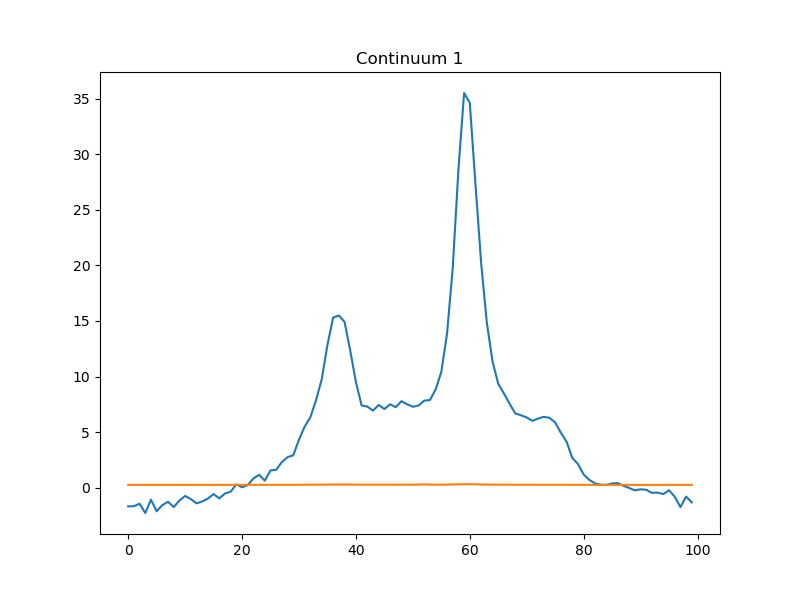

In [53]:
mask_continuum_1 = (wavelenghts > 4500)*(wavelenghts < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [54]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 100),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 44),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 100),
    (0.1, 10),
    (40, 50),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1310.5501326224712
differential_evolution step 2: f(x)= 1310.5501326224712
differential_evolution step 3: f(x)= 1174.7891535273877
differential_evolution step 4: f(x)= 881.7684721362162
differential_evolution step 5: f(x)= 881.7684721362162
differential_evolution step 6: f(x)= 714.4997041668051
differential_evolution step 7: f(x)= 635.0108141550446
differential_evolution step 8: f(x)= 635.0108141550446
differential_evolution step 9: f(x)= 635.0108141550446
differential_evolution step 10: f(x)= 635.0108141550446
differential_evolution step 11: f(x)= 635.0108141550446
differential_evolution step 12: f(x)= 635.0108141550446
differential_evolution step 13: f(x)= 635.0108141550446
differential_evolution step 14: f(x)= 635.0108141550446
differential_evolution step 15: f(x)= 635.0108141550446
differential_evolution step 16: f(x)= 608.5115567913142
differential_evolution step 17: f(x)= 432.99797416646095
differential_evolution step 18: f(x)= 432.99797416646

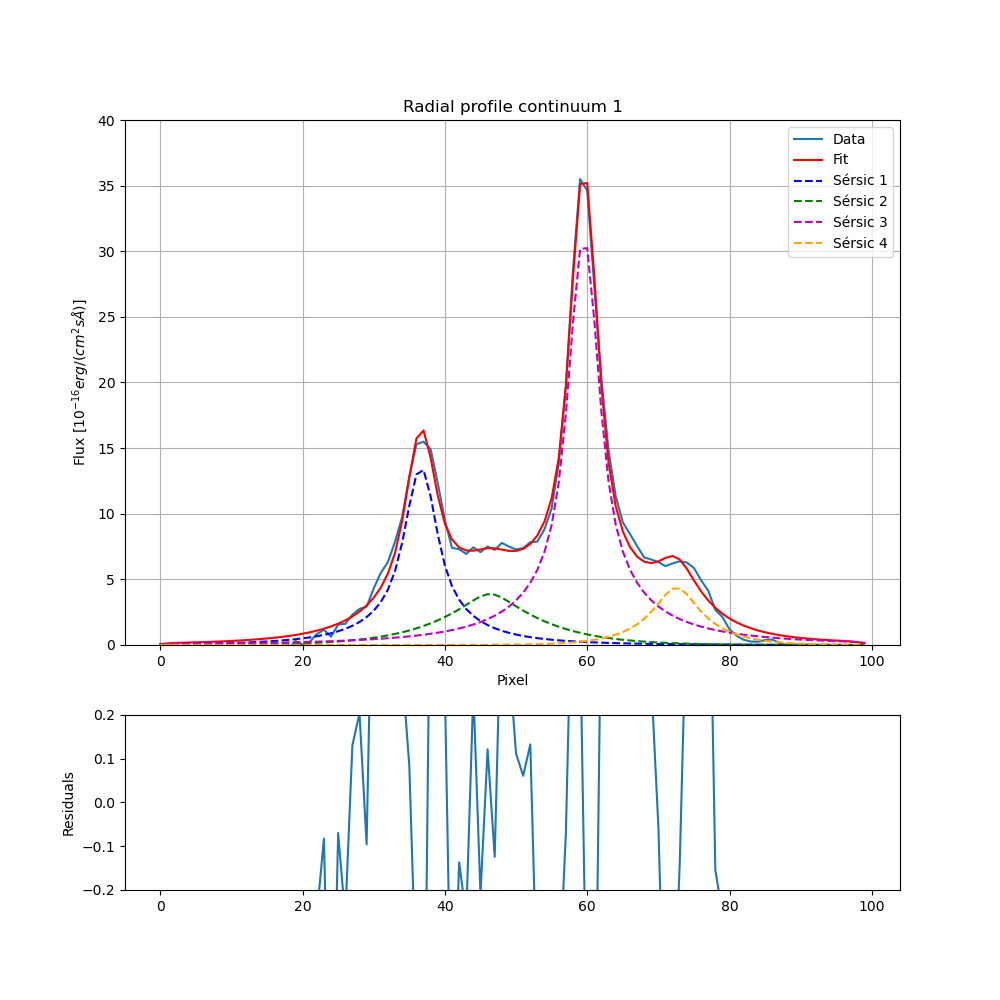

In [55]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_continuum_1, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile continuum 1")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 40)

ax[1].plot(x_axes, radial_profile_continuum_1 - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_continuum_1_diff')

In [56]:
params_curve_continuum_1, covariance_continuum_1 = curve_fit(model_convolved, x_axes, radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_continuum_1[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_continuum_1)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_continuum_1)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_continuum_1)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_continuum_1)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Continuum_1_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Continuum_1_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_continuum_1)))
#print(infodict.fvec**2)
chi2_continuum_1 = np.sum((((radial_profile_continuum_1 - model_convolved(x_axes, *params_curve_continuum_1)) / radial_profile_error_continuum_1)**2))
dof_continuum_1 = len(radial_profile_continuum_1) - len(params_curve_continuum_1)
chi2_reduced_continuum_1 = chi2_continuum_1 / dof_continuum_1
print(chi2_reduced_continuum_1)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1096764098.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1096764098.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Sérsic 1: I_e=8.6278, r_e=1.7344, n=0.1839, x_0=36.7303
Sérsic 2: I_e=5.5128, r_e=10.4440, n=0.2608, x_0=42.3823
Sérsic 3: I_e=5.4314, r_e=4.1666, n=1.4583, x_0=59.3441
Sérsic 4: I_e=5.2671, r_e=7.0714, n=0.1544, x_0=68.8179
[4.35129741 0.68799896 0.71519407 0.15550558 0.52795159 0.89231583
 0.05195176 1.17116076 5.35824277 2.09593942 0.49166414 0.0875513
 0.48268186 4.63890928 0.12055162 5.15445377]
8.644166060667365


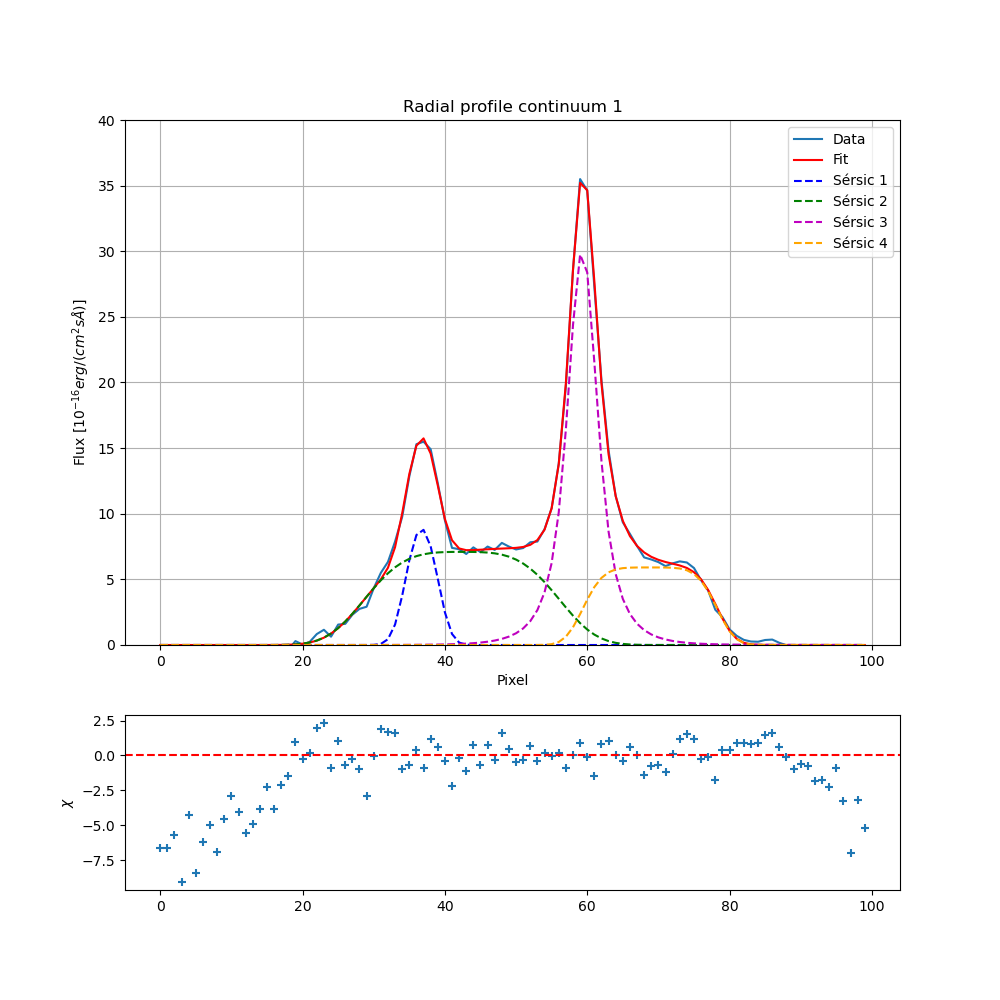

In [57]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_continuum_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_continuum_1, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_1[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_1[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_1[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_1[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile continuum 1")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 40)

ax[1].scatter(x_axes, (radial_profile_continuum_1 - y_fit)/radial_profile_error_continuum_1, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

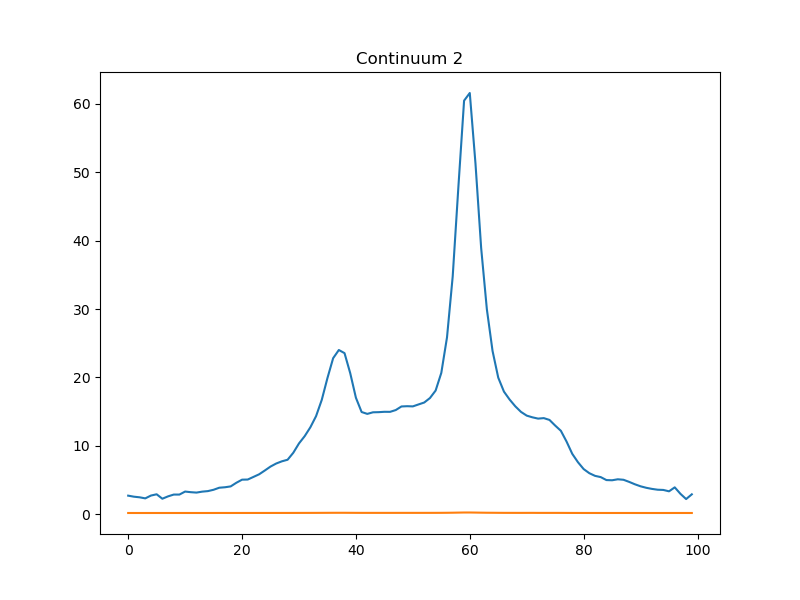

In [77]:
mask_continuum_2 = (wavelenghts > 5300)*(wavelenghts < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [78]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 100),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 44),   # x_0: circa la posizione di Halpha

    (0, 2),
    (0, 100),
    (0.1, 10),
    (40, 50),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 7593.728562970699
differential_evolution step 2: f(x)= 1324.0074050928986
differential_evolution step 3: f(x)= 1324.0074050928986
differential_evolution step 4: f(x)= 1324.0074050928986
differential_evolution step 5: f(x)= 1324.0074050928986
differential_evolution step 6: f(x)= 1076.8371125868714
differential_evolution step 7: f(x)= 1076.8371125868714
differential_evolution step 8: f(x)= 1076.8371125868714
differential_evolution step 9: f(x)= 1076.8371125868714
differential_evolution step 10: f(x)= 869.2370951900048
differential_evolution step 11: f(x)= 869.2370951900048
differential_evolution step 12: f(x)= 869.2370951900048
differential_evolution step 13: f(x)= 869.2370951900048
differential_evolution step 14: f(x)= 860.6517972290584
differential_evolution step 15: f(x)= 860.6517972290584
differential_evolution step 16: f(x)= 860.6517972290584
differential_evolution step 17: f(x)= 462.3945909296155
differential_evolution step 18: f(x)= 462.3945909

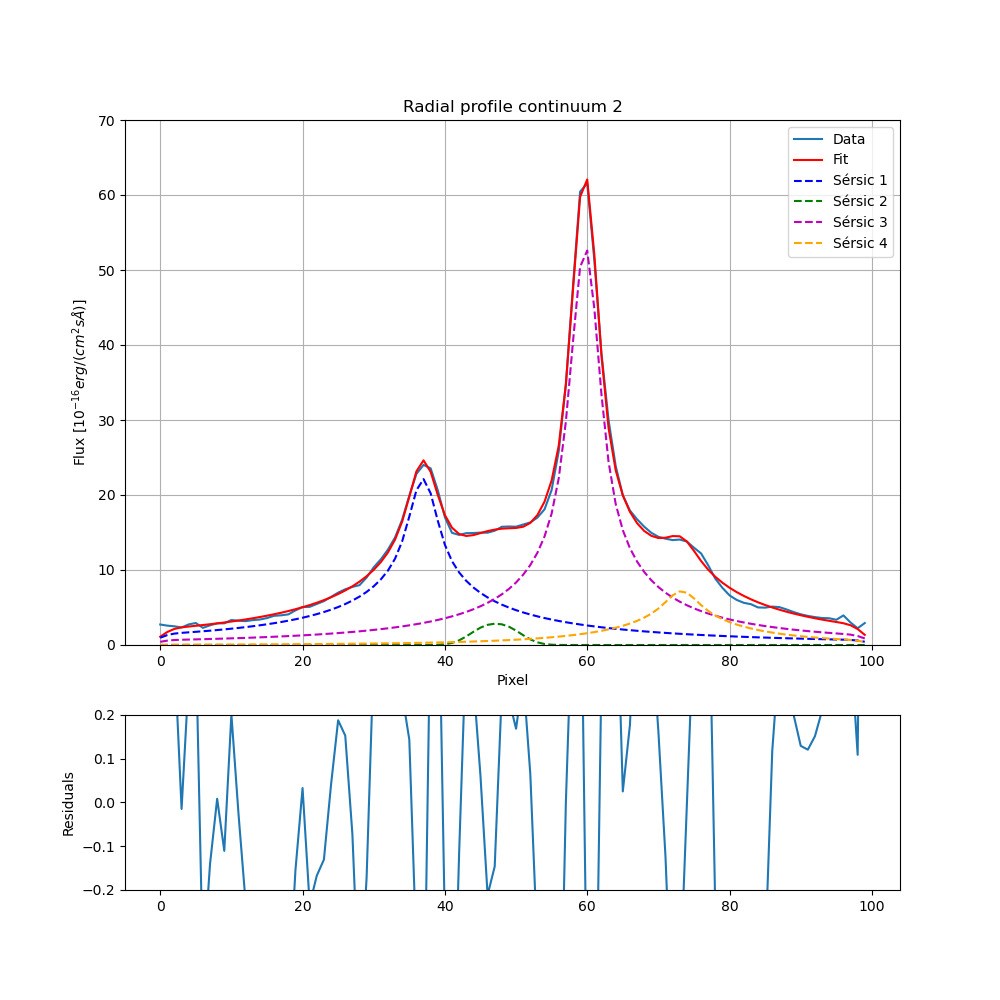

In [79]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_continuum_2, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile continuum 2")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 70)

ax[1].plot(x_axes, radial_profile_continuum_2 - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_continuum_2_diff')

In [86]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 100),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 44),   # x_0: circa la posizione di Halpha

    (0, 2),
    (0, 100),
    (0.1, 10),
    (40, 50),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (70, 80)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_2, covariance_continuum_2 = curve_fit(model_convolved, x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2, bounds = bounds_list, maxfev=15000)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_continuum_2[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_continuum_2)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_continuum_2)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_continuum_2)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_continuum_2)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Continuum_2_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Continuum_2_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_continuum_2)))
#print(infodict.fvec**2)
chi2_continuum_2 = np.sum((((radial_profile_continuum_2 - model_convolved(x_axes, *params_curve_continuum_2)) / radial_profile_error_continuum_2)**2))
dof_continuum_2 = len(radial_profile_continuum_2) - len(params_curve_continuum_2)
chi2_reduced_continuum_2 = chi2_continuum_2 / dof_continuum_2
print(chi2_reduced_continuum_2)

Sérsic 1: I_e=0.4939, r_e=64.7227, n=2.3884, x_0=36.8978
Sérsic 2: I_e=2.0000, r_e=2.8440, n=0.3217, x_0=47.1223
Sérsic 3: I_e=0.3260, r_e=99.1075, n=3.6341, x_0=59.6708
Sérsic 4: I_e=0.4555, r_e=28.1423, n=1.7478, x_0=73.3804
[2.64132693e-01 4.12476388e+01 3.45755216e-01 8.26127805e-02
 1.08176026e+00 8.52993512e-01 4.40429529e-01 4.35027518e-01
 4.79144954e-01 1.38526672e+02 9.70522153e-01 2.28143287e-02
 3.22226389e-01 2.92091410e+01 4.83125662e-01 2.59633440e-01]
6.886678702148375


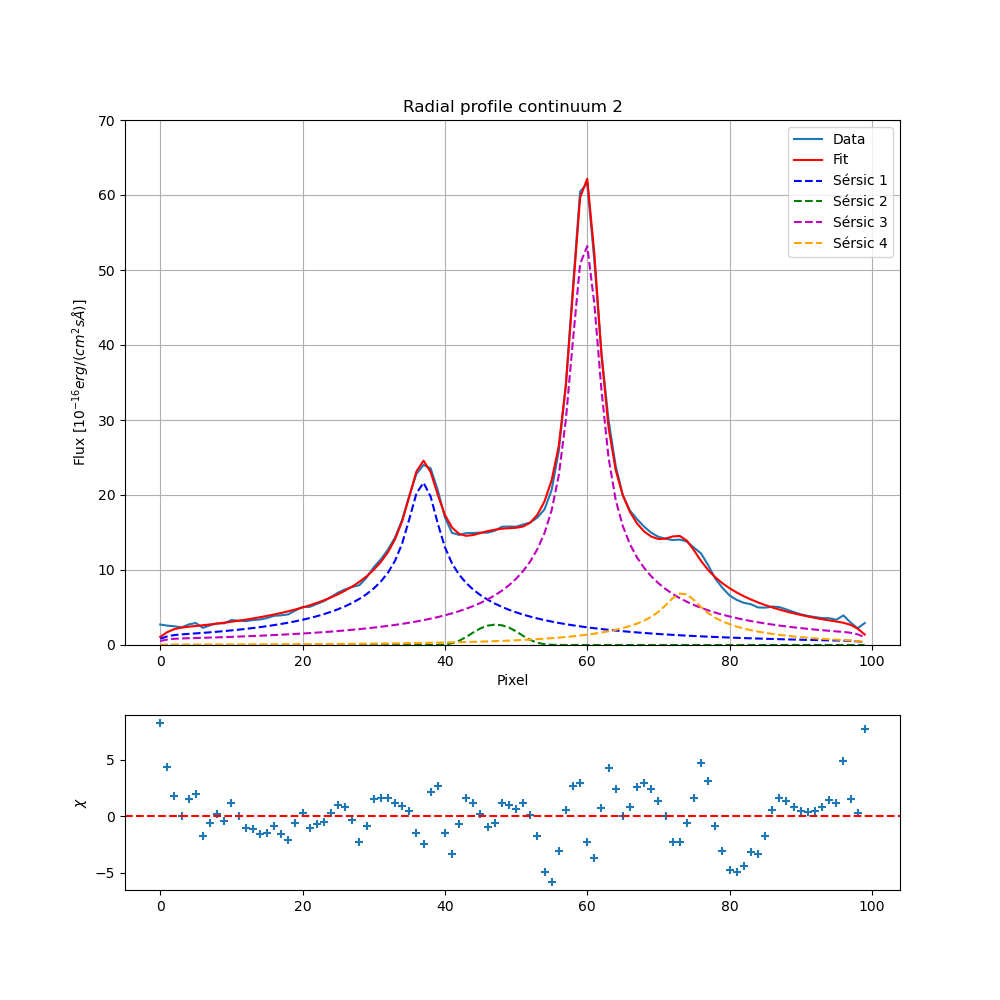

In [87]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_continuum_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_continuum_2, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_2[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_2[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_2[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile continuum 2")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 70)

ax[1].scatter(x_axes, (radial_profile_continuum_2 - y_fit)/radial_profile_error_continuum_2, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

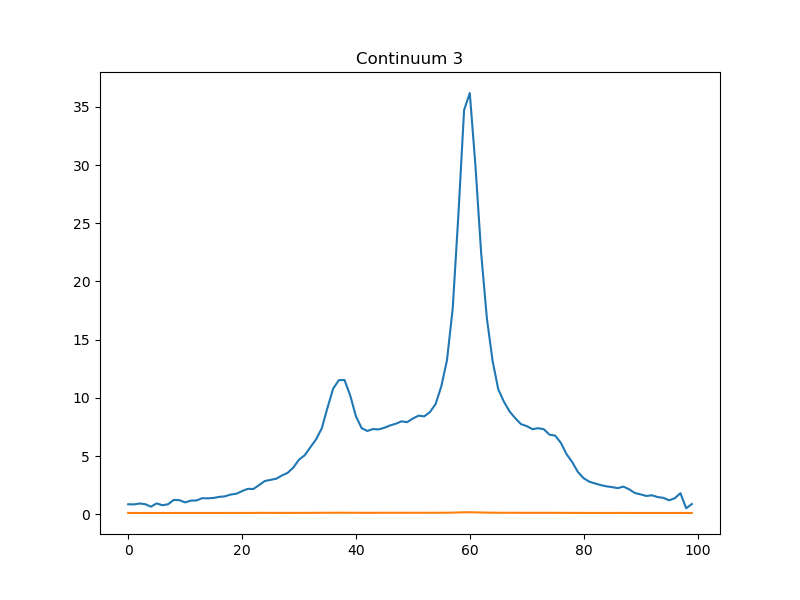

In [71]:
mask_continuum_3 = (wavelenghts > 6400)*(wavelenghts < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [72]:
sigma = 3.174 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 100),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (30, 44),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 100),
    (0.1, 10),
    (40, 50),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 100),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2295.7803699233546
differential_evolution step 2: f(x)= 1203.21802881526
differential_evolution step 3: f(x)= 776.5581727172109
differential_evolution step 4: f(x)= 705.4228064511159
differential_evolution step 5: f(x)= 583.6257987609632
differential_evolution step 6: f(x)= 402.7687978048141
differential_evolution step 7: f(x)= 402.7687978048141
differential_evolution step 8: f(x)= 300.3283906983022
differential_evolution step 9: f(x)= 300.3283906983022
differential_evolution step 10: f(x)= 300.3283906983022
differential_evolution step 11: f(x)= 271.53273297454933
differential_evolution step 12: f(x)= 271.53273297454933
differential_evolution step 13: f(x)= 211.36435517214932
differential_evolution step 14: f(x)= 164.8100775373367
differential_evolution step 15: f(x)= 164.8100775373367
differential_evolution step 16: f(x)= 164.8100775373367
differential_evolution step 17: f(x)= 164.8100775373367
differential_evolution step 18: f(x)= 164.810077537336

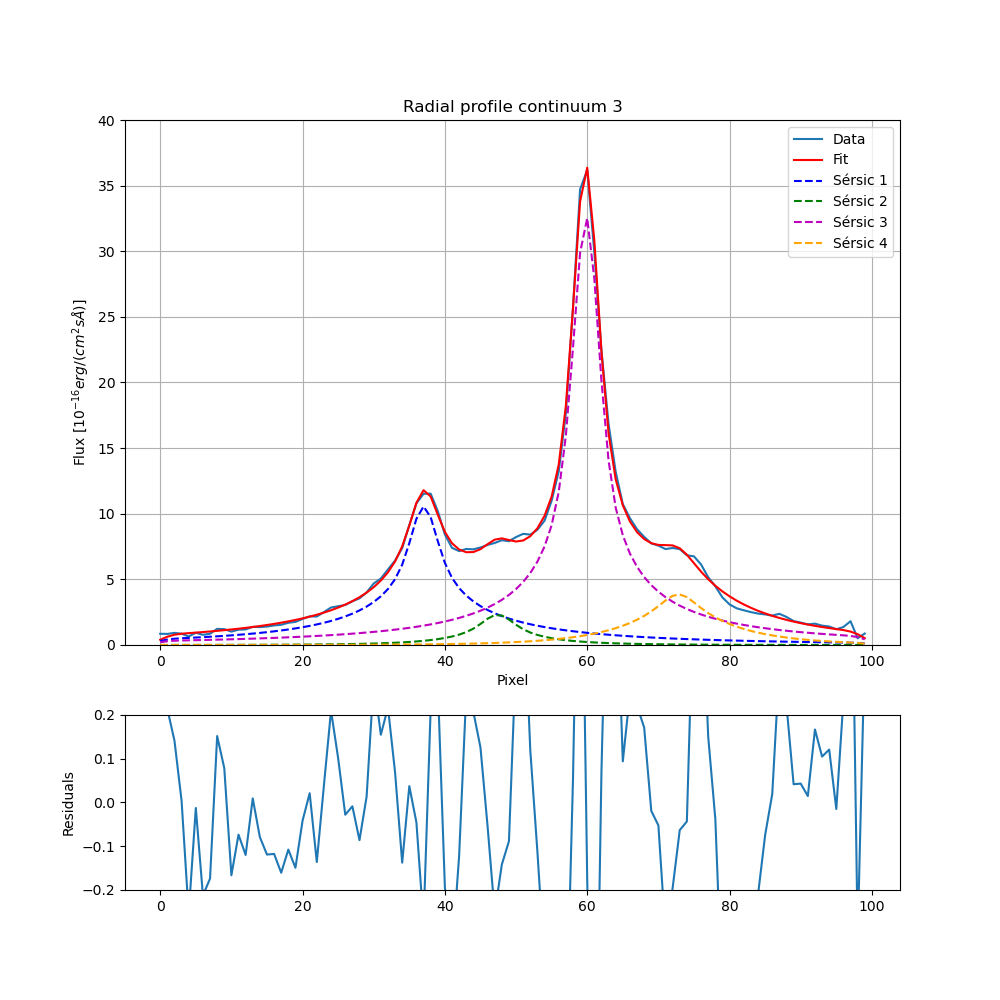

In [73]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_continuum_3, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile continuum 3")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 40)

ax[1].plot(x_axes, radial_profile_continuum_3 - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_continuum_3_diff')

In [74]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(model_convolved, x_axes, radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_continuum_3[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_continuum_3)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_continuum_3)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_continuum_3)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_continuum_3)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = { 'Component 1': [I_e[0], r_e[0], n[0], x_0_HA[0]], 'Component 2': [I_e[1], r_e[1], n[1], x_0_HA[1]], 
       'Component 3': [I_e[2], r_e[2], n[2], x_0_HA[2]], 'Component 4': [I_e[3], r_e[3], n[3], x_0_HA[3]]}
df1 = pd.DataFrame(data=d1, index =  ['I_e', 'r_e', 'n', 'x_0'])
df1.to_csv("Continuum_3_fit.csv", float_format='%.4f')

d2 = { 'Component 1': [I_e_err[0], r_e_err[0], n_err[0], x_0_err[0]], 'Component 2': [I_e_err[1], r_e_err[1], n_err[1], x_0_err[1]], 
       'Component 3': [I_e_err[2], r_e_err[2], n_err[2], x_0_err[2]], 'Component 4': [I_e_err[3], r_e_err[3], n_err[3], x_0_err[3]]}
df2 = pd.DataFrame(data=d2, index =  ['I_e error', 'r_e error', 'n error', 'x_0 error'])
df2.to_csv("Continuum_3_fit_error.csv", float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_continuum_3)))
#print(infodict.fvec**2)
chi2_continuum_3 = np.sum((((radial_profile_continuum_3 - model_convolved(x_axes, *params_curve_continuum_3)) / radial_profile_error_continuum_3)**2))
dof_continuum_3 = len(radial_profile_continuum_3) - len(params_curve_continuum_3)
chi2_reduced_continuum_3 = chi2_continuum_3 / dof_continuum_3
print(chi2_reduced_continuum_3)

Sérsic 1: I_e=0.3005, r_e=46.1096, n=2.2578, x_0=37.0568
Sérsic 2: I_e=0.2803, r_e=10.8035, n=1.4346, x_0=47.4667
Sérsic 3: I_e=0.2320, r_e=71.5609, n=3.5639, x_0=59.7862
Sérsic 4: I_e=0.6573, r_e=13.2717, n=1.1467, x_0=72.8759
[2.20644549e-01 3.59093785e+01 4.66974400e-01 9.88631905e-02
 8.90309495e-01 3.74333399e+01 2.07794460e+00 3.77443393e-01
 4.46223449e-01 1.13413540e+02 1.52909102e+00 1.67800307e-04
 2.95748884e-01 8.82848196e+00 3.36357151e-01 3.12259965e-01]
6.35308797574376


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1564170388.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_3844\1564170388.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


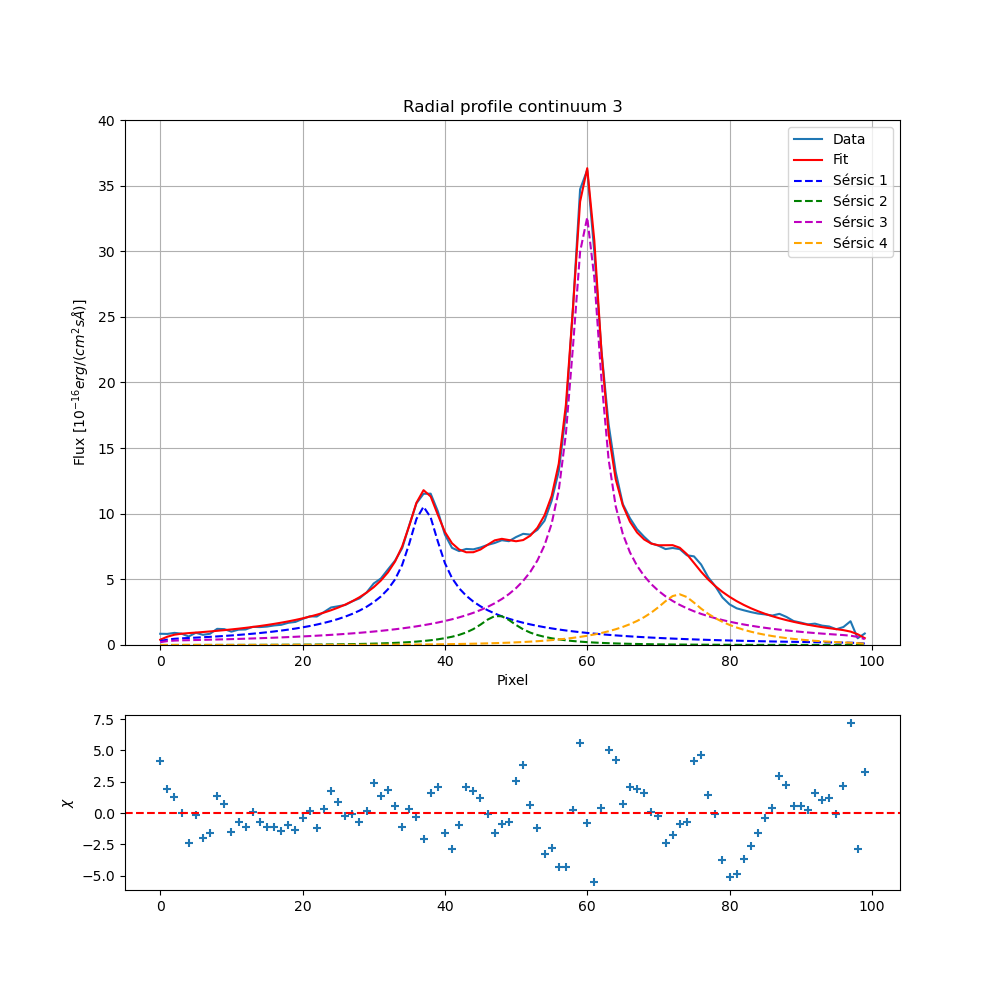

In [76]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_continuum_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_continuum_3, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_3[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_continuum_3[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
ax[0].set_title("Radial profile continuum 3")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 40)

ax[1].scatter(x_axes, (radial_profile_continuum_3 - y_fit)/radial_profile_error_continuum_3, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [89]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)